# Validación empírica — IPC Argentina (dic-2016 → abr-2026)

Complemento empírico de la tesis MECTESIS. Compara modelos clásicos contra Chronos-2 sobre una serie macro real, replicando la estructura de tres regímenes ya tratados en simulación:

1. **Univariado** sobre inflación mensual IPC.
2. **Multivariado** con un sistema macro endógeno (π, TCM, M2, BADLAR).
3. **Covariadas** observadas (IPC ~ TCM, REM, BADLAR).

**Series del panel** (CSV único `data/raw/data.csv`):

| Variable | Definición | Unidad |
|---|---|---|
| `ipc` | Inflación mensual (INDEC IPC Nacional) | % |
| `tpm` | Tasa de política monetaria | % nominal |
| `badlar` | Tasa BADLAR bancos privados | % nominal |
| `tcm` | Tipo de cambio mayorista A3500 | ARS/USD (nivel) |
| `m2` | M2 privado, variación interanual (p.m. 30 días) | % yoy |
| `rem` | Mediana REM expectativa inflación 12m | % |

**Transformaciones:** IPC y M2 ya vienen en tasa, se usan directamente. TCM en nivel → `dlog_tcm = 100·Δlog(TCM)`. Tasas en niveles para covariadas; diferenciadas para multivariado estacionario.

**Modelos:** AutoARIMA / AutoETS / AutoTheta (wrappers sobre `statsforecast` de Nixtla), SARIMAX, VAR/VECM, Chronos-2.

**Evaluación:** rolling-origin (expanding window, refit por origen) con horizontes h ∈ {1, 3, 6, 12} y métricas RMSE / MAE / CRPS / coverage80,95 / Winkler80,95 / mean-width80,95.

## 0 · Setup y carga del panel

In [1]:
import sys, warnings, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mectesis.empirical.loaders import build_panel
from mectesis.empirical.transforms import log_diff
from mectesis.empirical import diagnostics as diag
from mectesis.empirical import describe as desc
from mectesis.empirical.backtest import compare_models
from mectesis.empirical.autoselect import AutoARIMAModel, AutoETSModel, AutoThetaModel
from mectesis.models.sarimax_model import SARIMAXModel
from mectesis.models.var_model import VARModel, VECMModel
from mectesis.models.chronos import ChronosModel
from mectesis.models.chronos_multivariate import ChronosMultivariateModel
from mectesis.models.chronos_covariate import ChronosCovariateModel

START, END = "2016-12-01", "2026-05-01"
INITIAL_WINDOW = 72
HORIZONS = [1, 3, 6, 12]

In [2]:
panel = build_panel(start=START, end=END)
print(f"Panel shape: {panel.shape}, rango {panel.index.min().date()} → {panel.index.max().date()}")
print(panel.isna().sum())
panel.head()

Panel shape: (113, 6), rango 2016-12-01 → 2026-04-01
ipc       0
tpm       0
badlar    0
tcm       0
m2        0
rem       0
dtype: int64


,ipc,tpm,badlar,tcm,m2,rem
fecha,,,,,,
2016-12-01,1.2,23.1,20.0,15.8296,22.2,19.6
2017-01-01,1.3,21.8,19.8,15.9065,28.6,19.7
2017-02-01,2.5,21.0,20.1,15.5983,30.7,19.5
2017-03-01,2.4,21.5,19.5,15.5237,31.9,18.4
2017-04-01,2.6,22.6,19.2,15.3600,31.9,17.5


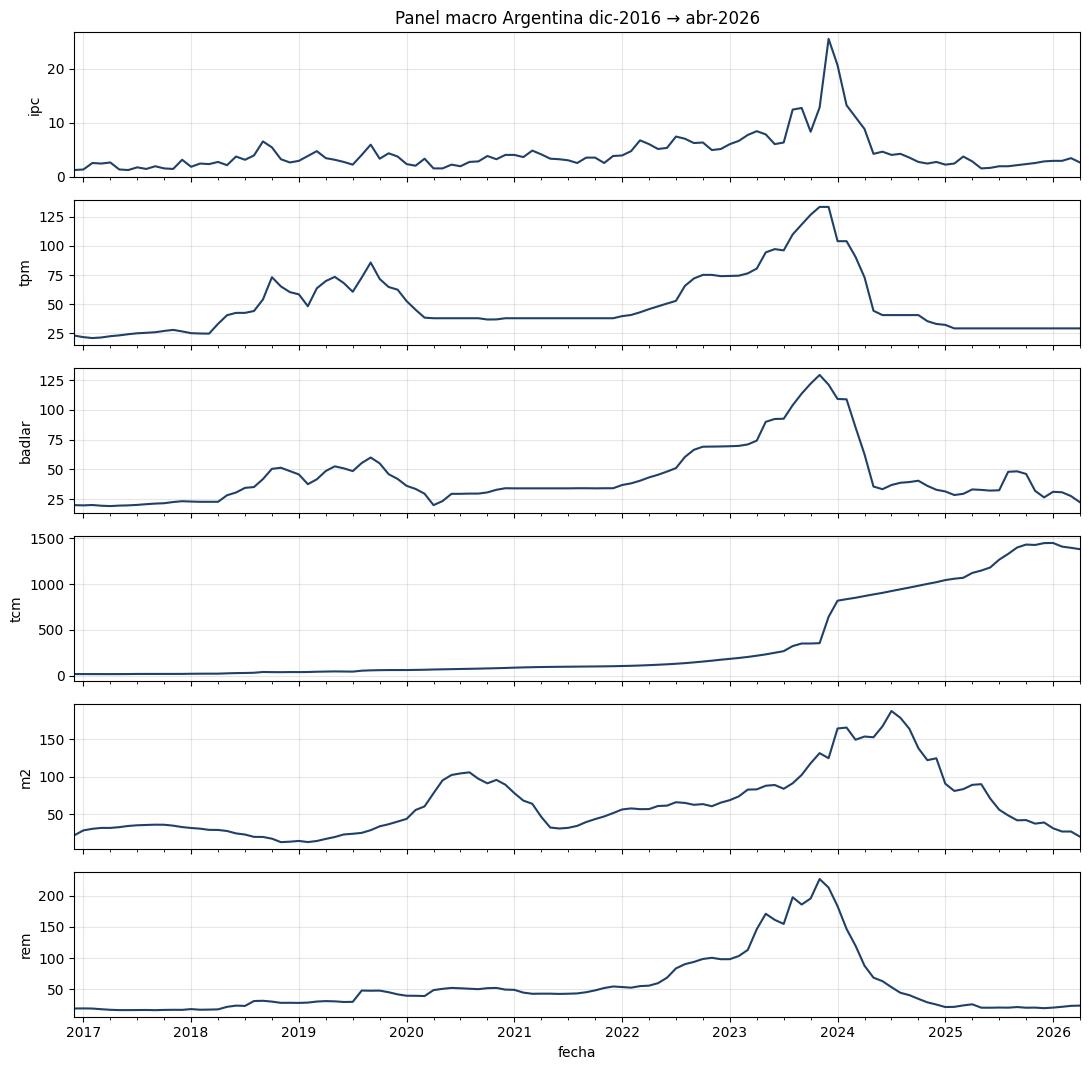

In [3]:
desc.plot_panel(panel, title="Panel macro Argentina dic-2016 → abr-2026")
plt.show()

## 1 · Validación univariada (IPC = π mensual)

El IPC del panel ya está en tasa de inflación mensual %; se usa directamente como target. Modelos:
- **AutoARIMA** — Hyndman-Khandakar (AICc) vía statsforecast.
- **AutoETS** — selección AICc sobre familia ETS vía statsforecast.
- **AutoTheta** — Standard/Optimized/Dyn variants vía statsforecast.
- **Chronos-2** zero-shot.

  n      start        end     mean      std  min  p25  median  p75  max     skew  kurtosis
113 2016-12-01 2026-04-01 4.342478 3.578378  1.2  2.4     3.3  4.9 25.5 3.231683 13.896354


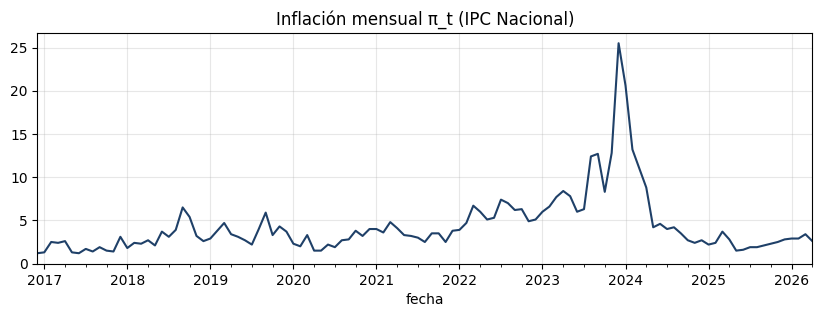

In [4]:
pi = panel["ipc"].rename("pi")
print(desc.summary_stats(pi).to_string(index=False))
desc.plot_series(pi, title="Inflación mensual π_t (IPC Nacional)")
plt.show()

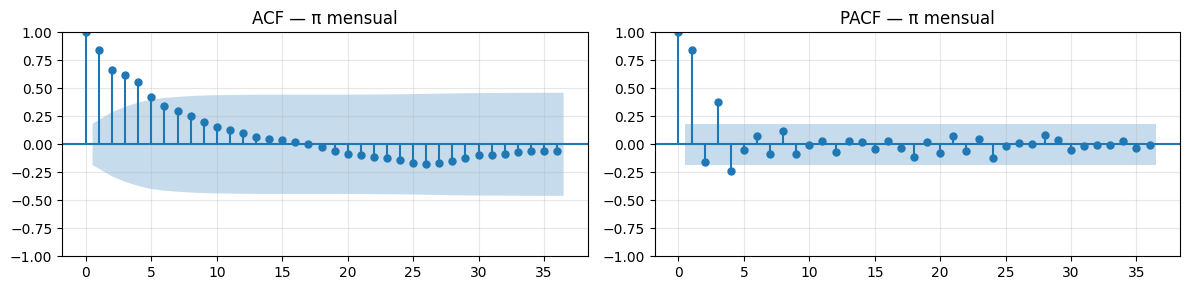

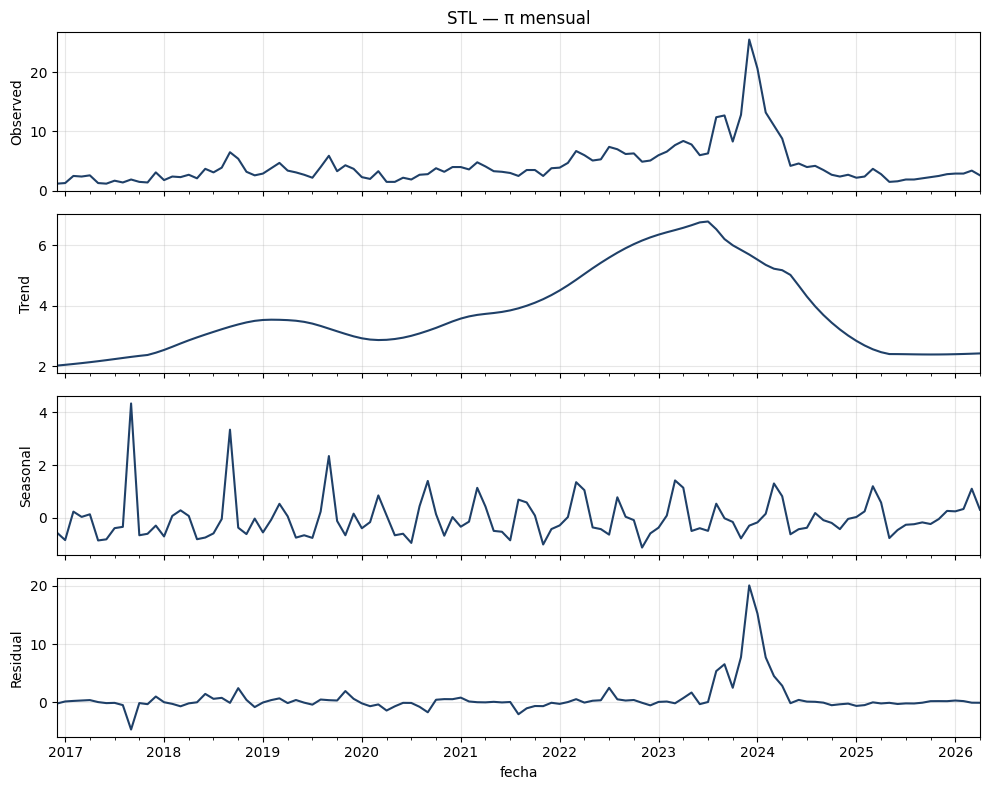

In [5]:
desc.plot_acf_pacf(pi, lags=36, title="π mensual"); plt.show()
desc.plot_decomposition(pi, period=12, title="π mensual"); plt.show()

### 1.1 Tests estadísticos (estilo paper)

In [6]:
print("=== Raíz unitaria sobre π (nivel) ===")
print(diag.unit_root_battery(pi).to_string(index=False))
print("\n=== Autocorrelación (Ljung-Box) ===")
print(diag.serial_correlation(pi).to_string(index=False))
print("\n=== Heterocedasticidad (ARCH-LM) ===")
print(diag.heteroscedasticity(pi).to_string(index=False))
print("\n=== Normalidad (Jarque-Bera) ===")
print(diag.normality(pi).to_string(index=False))
print("\n=== Quiebres estructurales (PELT) ===")
print(diag.structural_breaks(pi).to_string(index=False))

=== Raíz unitaria sobre π (nivel) ===
         test regression      stat   pvalue  used_lag  nobs                                  conclusion
          ADF          c -2.702809 0.073553       3.0 109.0         do not reject H0 (unit root) @ 0.05
          ADF         ct -2.718121 0.228636       3.0 109.0         do not reject H0 (unit root) @ 0.05
         KPSS          c  0.420867 0.068161       5.0 113.0        do not reject H0 (stationary) @ 0.05
         KPSS         ct  0.148015 0.048321       5.0 113.0               reject H0 (stationary) @ 0.05
Zivot-Andrews          c -4.329284 0.179397       NaN   NaN do not reject H0 (unit root w/break) @ 0.05

=== Autocorrelación (Ljung-Box) ===
     test  lag       stat       pvalue                     conclusion
Ljung-Box   12 281.898057 2.939776e-53 reject H0 (no autocorr) @ 0.05
Ljung-Box   24 292.727161 4.868406e-48 reject H0 (no autocorr) @ 0.05

=== Heterocedasticidad (ARCH-LM) ===
   test  nlags      stat       pvalue   f_stat     f_

### 1.2 Comparación de modelos vía rolling-origin

In [7]:
uni_results = compare_models(
    factories={
        "AutoARIMA": lambda: AutoARIMAModel(season_length=12),
        "AutoETS":   lambda: AutoETSModel(season_length=12),
        "AutoTheta": lambda: AutoThetaModel(season_length=12),
        "Chronos-2": lambda: ChronosModel(device="cpu"),
    },
    y=pi,
    horizons=HORIZONS,
    initial_window=INITIAL_WINDOW,
    verbose=True,
)
uni_results

[backtest] AutoARIMA
[backtest] AutoETS
[backtest] AutoTheta
[backtest] Chronos-2


,model,horizon,n_origins,rmse,mae,bias,cov80,width80,winkler80,cov95,width95,winkler95,crps
0,AutoARIMA,1,30,3.648386,2.375470,-0.061689,0.600000,3.775722,15.356751,0.800000,5.774469,41.969233,1.923596
1,AutoARIMA,3,30,6.169301,4.039661,-0.551768,0.533333,6.059941,29.962572,0.700000,9.267879,86.682756,3.471898
2,AutoARIMA,6,30,7.464070,4.892016,-0.944543,0.566667,7.860113,39.916859,0.600000,12.021005,116.867311,4.446905
3,AutoARIMA,12,30,8.793635,6.314945,-2.584927,0.433333,10.226947,51.009747,0.466667,15.640766,144.843408,5.722359
4,AutoETS,1,30,3.644562,2.160844,-0.134437,0.800000,5.391365,10.737498,0.933333,8.245381,22.316223,1.590883
5,AutoETS,3,30,5.678321,3.827358,-0.715947,0.666667,8.258140,15.666681,0.833333,12.629735,25.104999,2.674185
6,AutoETS,6,30,7.972824,5.264725,-1.647271,0.766667,12.041087,24.703511,0.833333,18.415254,59.983755,3.873911
7,AutoETS,12,30,9.768517,7.000739,-3.563006,0.833333,19.755668,29.252745,0.900000,30.213688,57.747789,4.716025
8,AutoTheta,1,30,3.782885,2.337883,-0.175385,0.666667,4.568325,16.319500,0.666667,6.016432,44.452343,1.966544
9,AutoTheta,3,30,5.708029,3.781499,-0.510639,0.633333,7.352464,25.949272,0.733333,10.746585,67.348634,3.191596


## 2 · Validación multivariada (sistema endógeno π, TCM, M2, BADLAR)

Variables endógenas en transformaciones estacionarias:
- `pi`        — inflación mensual % (ya estacionaria por construcción).
- `dlog_tcm`  — 100·Δlog(TCM), depreciación mensual.
- `m2`        — variación interanual M2 (ya viene en tasa).
- `d_badlar`  — Δ tasa BADLAR (primera diferencia para remover tendencia).

REM se reserva para Sec 3 (variable forward-looking, mejor como exógena). Modelos: VAR, VECM si Johansen rechaza r=0, ChronosMultivariateModel.

Y shape: (112, 4)


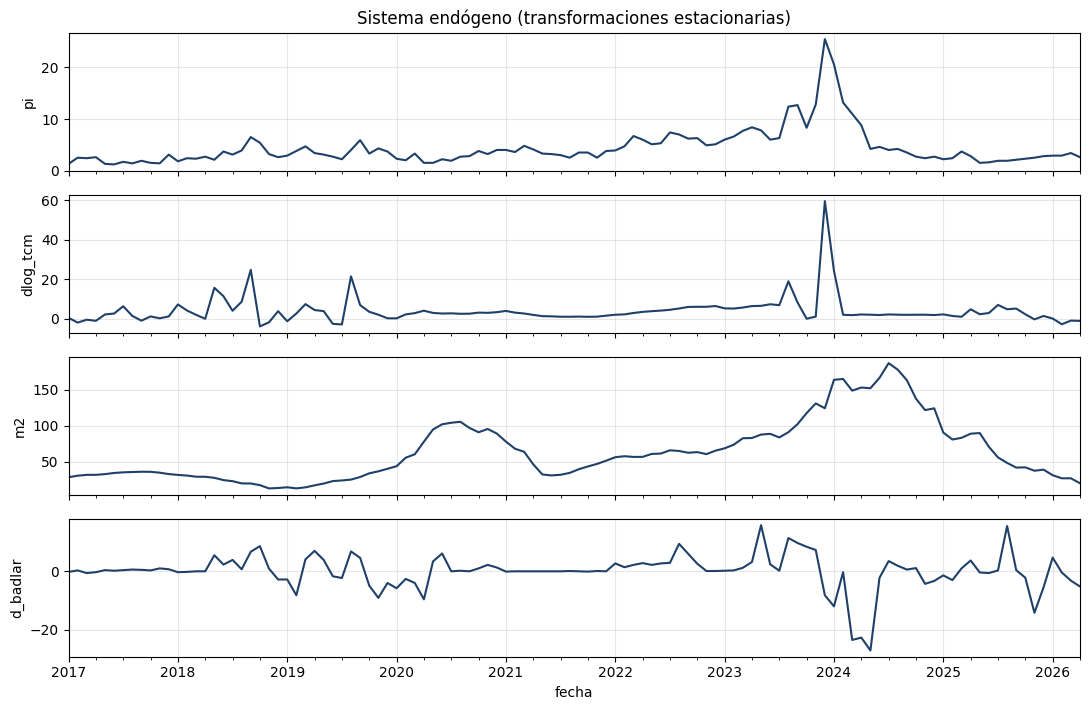

In [8]:
Y = pd.concat({
    "pi":       panel["ipc"],
    "dlog_tcm": log_diff(panel["tcm"], 100),
    "m2":       panel["m2"],
    "d_badlar": panel["badlar"].diff(),
}, axis=1).dropna()
print(f"Y shape: {Y.shape}")
desc.plot_panel(Y, title="Sistema endógeno (transformaciones estacionarias)"); plt.show()

In [9]:
print("=== Granger causality (min p-value sobre lags 1..6) — fila ← columna ===")
print(diag.granger_matrix(Y, maxlag=6).round(3))

# Johansen sobre log-niveles (donde aplica) para chequear cointegración
log_levels = pd.concat({
    "log_tcm":  np.log(panel["tcm"]),
    "badlar":   panel["badlar"],
    "m2":       panel["m2"],
}, axis=1).dropna()
print("\n=== Johansen (det_order=0, k_ar_diff=1) sobre log_tcm, badlar, m2 ===")
print(diag.johansen_test(log_levels, det_order=0, k_ar_diff=1).to_string(index=False))

=== Granger causality (min p-value sobre lags 1..6) — fila ← columna ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.5899  , p=0.2101  , df_denom=108, df_num=1
ssr based chi2 test:   chi2=1.6341  , p=0.2011  , df=1
likelihood ratio test: chi2=1.6222  , p=0.2028  , df=1
parameter F test:         F=1.5899  , p=0.2101  , df_denom=108, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.5035  , p=0.0022  , df_denom=105, df_num=2
ssr based chi2 test:   chi2=13.6263 , p=0.0011  , df=2
likelihood ratio test: chi2=12.8461 , p=0.0016  , df=2
parameter F test:         F=6.5035  , p=0.0022  , df_denom=105, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.0716  , p=0.3646  , df_denom=102, df_num=3
ssr based chi2 test:   chi2=3.4353  , p=0.3292  , df=3
likelihood ratio test: chi2=3.3823  , p=0.3364  , df=3
parameter F test:         F=1.0716  , p=0.3646  , df_denom=102, df_num=3

Granger Causality
nu

In [10]:
multi_results = compare_models(
    factories={
        "VAR(1)": lambda: VARModel(lags=1),
        "VAR(2)": lambda: VARModel(lags=2),
        # "VECM":   lambda: VECMModel(coint_rank=1, k_ar_diff=1),  # habilitar si Johansen rechaza r=0
        "ChronosMultivariate": lambda: ChronosMultivariateModel(device="cpu"),
    },
    y=Y,
    horizons=HORIZONS,
    initial_window=INITIAL_WINDOW,
    verbose=True,
)
multi_results

[backtest] VAR(1)
[backtest] VAR(2)
[backtest] ChronosMultivariate


TypeError: ChronosMultivariateModel.__init__() got an unexpected keyword argument 'device'

## 3 · Validación con covariables (IPC ~ X)

X = {`dlog_tcm`, `rem`, `badlar`}. REM es la mejor exógena natural para inflación (forward-looking).

Modelos: SARIMAX (order desde AutoARIMA de Sec 1, exog = X), ChronosCovariateModel.

In [11]:
pi_cov = panel["ipc"].rename("pi")
X = pd.concat({
    "dlog_tcm": log_diff(panel["tcm"], 100),
    "rem":      panel["rem"],
    "badlar":   panel["badlar"],
}, axis=1).reindex(pi_cov.index).dropna()
pi_cov = pi_cov.loc[X.index]
print(f"pi: {pi_cov.shape}, X: {X.shape}")

pi: (112,), X: (112, 3)


In [12]:
print("=== Correlaciones contemporáneas ===")
print(diag.contemp_corr(pd.concat([pi_cov, X], axis=1)).round(3))
for col in X.columns:
    print(f"\n=== Cross-corr π × {col} (lag −12..+12) ===")
    cc = diag.cross_corr(pi_cov, X[col], max_lag=12)
    print(cc.set_index("lag").round(3).T)

=== Correlaciones contemporáneas ===
             pi  dlog_tcm    rem  badlar
pi        1.000     0.671  0.843   0.836
dlog_tcm  0.671     1.000  0.450   0.442
rem       0.843     0.450  1.000   0.927
badlar    0.836     0.442  0.927   1.000

=== Cross-corr π × dlog_tcm (lag −12..+12) ===
lag     -12    -11    -10    -9     -8     -7    -6     -5     -4     -3   \
corr -0.014  0.022  0.029  0.053  0.069  0.062  0.05  0.124  0.231  0.213   

lag   ...     3      4      5      6      7      8     9      10     11     12  
corr  ...  0.305  0.308  0.192  0.173  0.148  0.115  0.06  0.011  0.003  0.032  

[1 rows x 25 columns]

=== Cross-corr π × rem (lag −12..+12) ===
lag     -12    -11    -10    -9     -8     -7     -6     -5     -4     -3   \
corr  0.106  0.148  0.198  0.245  0.294  0.348  0.399  0.455  0.529  0.615   

lag   ...     3      4      5     6      7      8      9      10     11    12  
corr  ...  0.818  0.782  0.699  0.63  0.585  0.511  0.416  0.335  0.264  0.21  

[1 rows x

In [13]:
cov_results = compare_models(
    factories={
        "SARIMAX(1,0,0)": lambda: SARIMAXModel(order=(1, 0, 0)),
        "SARIMAX(1,0,1)": lambda: SARIMAXModel(order=(1, 0, 1)),
        "ChronosCov":     lambda: ChronosCovariateModel(device="cpu"),
    },
    y=pi_cov,
    X=X,
    horizons=HORIZONS,
    initial_window=INITIAL_WINDOW,
    verbose=True,
)
cov_results

[backtest] SARIMAX(1,0,0)
[backtest] SARIMAX(1,0,1)
[backtest] ChronosCov


TypeError: ChronosCovariateModel.__init__() got an unexpected keyword argument 'device'

## 4 · Síntesis

Tabla maestra (modelo × sección × horizonte) y export a `results/empirical/`.

In [ ]:
uni = uni_results.assign(seccion="univariada")
mul = multi_results.assign(seccion="multivariada")
cov = cov_results.assign(seccion="covariadas")
master = pd.concat([uni, mul, cov], ignore_index=True)

out_dir = pathlib.Path.cwd().parent / "results" / "empirical"
out_dir.mkdir(parents=True, exist_ok=True)
master.to_csv(out_dir / "tabla_maestra.csv", index=False)
print(f"Guardado: {out_dir / 'tabla_maestra.csv'}")
master